In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [2]:
%cd /content/gdrive/MyDrive/stock-predictions

/content/gdrive/MyDrive/stock-predictions


#Model Training

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

from src.data.collector import StockDataCollector
from src.data.preprocessor import DataPreprocessor
from src.data.dataset import StockSequenceDataset, create_dataloaders
from src.features.technical import TechnicalIndicators
from src.models.lstm_model import LSTMPredictor
from src.models.tree_models import TreeEnsemble
from src.models.ensemble import EnsembleModel
from src.training.trainer import LSTMTrainer
from src.training.hyperopt import HyperparameterSearch, SMALL_GRID
from src.evaluation.metrics import TradingMetrics

plt.style.use('seaborn-v0_8-darkgrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
SEQ_LEN = 20
TICKER = 'AAPL'

Device: cuda


## 1. Data Setup

In [4]:
# Pool all 10 tickers into one dataset for a much larger training set (~15k samples)
ALL_TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'GS', 'SPY', 'QQQ']
collector = StockDataCollector(tickers=ALL_TICKERS)
prices = collector.download_prices(start='2017-04-26', end='2026-04-26')

preprocessor = DataPreprocessor()

# Load sentiment once
import os as _os
_sent_path = '../data/daily_sentiment.csv'
sent_df = None
if _os.path.exists(_sent_path):
    import pandas as _pd
    sent_df = _pd.read_csv(_sent_path, parse_dates=['date'])
    print(f'Loaded sentiment CSV: {len(sent_df)} rows')
else:
    print('No sentiment file — run notebook 1 first. Using zeros.')

# Per-ticker chronological split (70/15/15), then concatenate
tr_X, va_X, te_X, tr_ret, va_ret, te_ret = [], [], [], [], [], []
feature_cols = None

for ticker in ALL_TICKERS:
    try:
        ohlcv, _ = preprocessor.preprocess_prices(prices, ticker)
        feat = TechnicalIndicators.compute_all(ohlcv)

        if sent_df is not None:
            s = sent_df[sent_df['ticker'] == ticker].set_index('date')['sentiment_score']
            feat['sentiment_score'] = feat.index.map(s).fillna(0.0)
        else:
            feat['sentiment_score'] = 0.0

        combined = feat.join(ohlcv[['LogReturn']], how='inner').dropna()
        ret = combined['LogReturn'].values
        if feature_cols is None:
            feature_cols = [c for c in combined.columns if c != 'LogReturn']
        X = combined[feature_cols].values

        n = len(X)
        te = int(n * 0.70); ve = int(n * 0.85)
        tr_X.append(X[:te]);  va_X.append(X[te:ve]);  te_X.append(X[ve:])
        tr_ret.append(ret[:te]); va_ret.append(ret[te:ve]); te_ret.append(ret[ve:])
    except Exception as e:
        print(f'Skipping {ticker}: {e}')

import numpy as np
X_train_raw = np.concatenate(tr_X)
X_val_raw   = np.concatenate(va_X)
X_test_raw  = np.concatenate(te_X)
returns_train = np.concatenate(tr_ret)
returns_val   = np.concatenate(va_ret)
returns_test  = np.concatenate(te_ret)

# Scaler fit on pooled training data only
preprocessor.fit_scaler(X_train_raw)
X_train = preprocessor.transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

# Keep single-ticker arrays for TICKER for per-stock evaluation later
ohlcv_ref, _ = preprocessor.preprocess_prices(prices, TICKER)
feat_ref = TechnicalIndicators.compute_all(ohlcv_ref)
if sent_df is not None:
    s = sent_df[sent_df['ticker'] == TICKER].set_index('date')['sentiment_score']
    feat_ref['sentiment_score'] = feat_ref.index.map(s).fillna(0.0)
else:
    feat_ref['sentiment_score'] = 0.0
combined_ref = feat_ref.join(ohlcv_ref[['LogReturn']], how='inner').dropna()
returns_ref = combined_ref['LogReturn'].values
X_ref = preprocessor.transform(combined_ref[feature_cols].values)

n_sent = (np.concatenate(tr_X + va_X + te_X)[:,feature_cols.index('sentiment_score')] != 0).sum() if 'sentiment_score' in feature_cols else 0
print(f'Tickers loaded: {len(tr_X)}')
print(f'Sentiment non-zero days: {n_sent}')
print(f'Features: {X_train.shape[1]}')
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

Loaded sentiment CSV: 146 rows
Tickers loaded: 10
Sentiment non-zero days: 68
Features: 21
Train: 15,470  Val: 3,320  Test: 3,320


## 2. PyTorch DataLoaders

In [5]:
train_ds = StockSequenceDataset(X_train, returns_train, SEQ_LEN)
val_ds   = StockSequenceDataset(X_val,   returns_val,   SEQ_LEN)
test_ds  = StockSequenceDataset(X_test,  returns_test,  SEQ_LEN)

train_loader, val_loader, test_loader = create_dataloaders(
    train_ds, val_ds, test_ds, batch_size=32  # 32 doubles batches vs 64
)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'Train class distribution: {train_ds.class_distribution}')
print(f'Input shape per batch: {next(iter(train_loader))[0].shape}')

# Compute class weights from pooled training labels
labels = (returns_train > 0).astype(int)
class_weights_np = preprocessor.compute_class_weights(labels)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)
print(f'Class weights: {class_weights}')

Train batches: 482 | Val batches: 104 | Test batches: 104
Train class distribution: {0: 7252, 1: 8198}
Input shape per batch: torch.Size([32, 20, 21])
Class weights: tensor([1.0657, 0.9419])


## 3. LSTM Training with Regularization

In [6]:
# Train the best LSTM configuration
model = LSTMPredictor(
    input_size=X_train.shape[1],
    hidden_size=128,
    num_layers=2,
    dropout=0.3,  # Regularization technique 1: dropout
)
print(model)
print()

trainer = LSTMTrainer(
    model=model,
    learning_rate=1e-3,
    weight_decay=1e-4,  # Regularization technique 2: L2 weight decay
    patience=15,         # Regularization technique 3: early stopping
    class_weights=class_weights,
    device=DEVICE,
)

history = trainer.fit(train_loader, val_loader, epochs=100, verbose=True, print_every=1)
print(f'\nTraining complete. Epochs trained: {len(history["train_loss"])}')
print(f'Best val_loss : {min(history["val_loss"]):.4f}')
print(f'Best val_acc  : {max(history["val_acc"]):.4f}')

LSTMPredictor(hidden=128, layers=2, params=218,050)

Training on cuda | lr=1.00e-03  wd=1.00e-04  max_epochs=100
 Epoch   TrainLoss    ValLoss   TrainAcc    ValAcc         LR     Time
------------------------------------------------------------------------
     1      0.7549     0.7052     0.4988    0.5167   1.00e-03     2.5s
     2      0.7113     0.6908     0.5064    0.5667   1.00e-03     4.6s
     3      0.7015     0.6905     0.5112    0.5682   1.00e-03     6.8s
     4      0.6979     0.6978     0.5036    0.4339   1.00e-03     8.9s
     5      0.6959     0.6912     0.5009    0.5515   1.00e-03    11.0s
     6      0.6944     0.6919     0.5039    0.5452   1.00e-03    13.3s
     7      0.6944     0.6931     0.5042    0.4773   1.00e-03    15.6s
     8      0.6938     0.6927     0.5047    0.5112   1.00e-03    17.7s
     9      0.6940     0.6946     0.5070    0.4597   1.00e-03    19.8s
    10      0.6930     0.6944     0.5125    0.4761   5.00e-04    21.9s
    11      0.6930     0.6934    

## 4. Training Curves

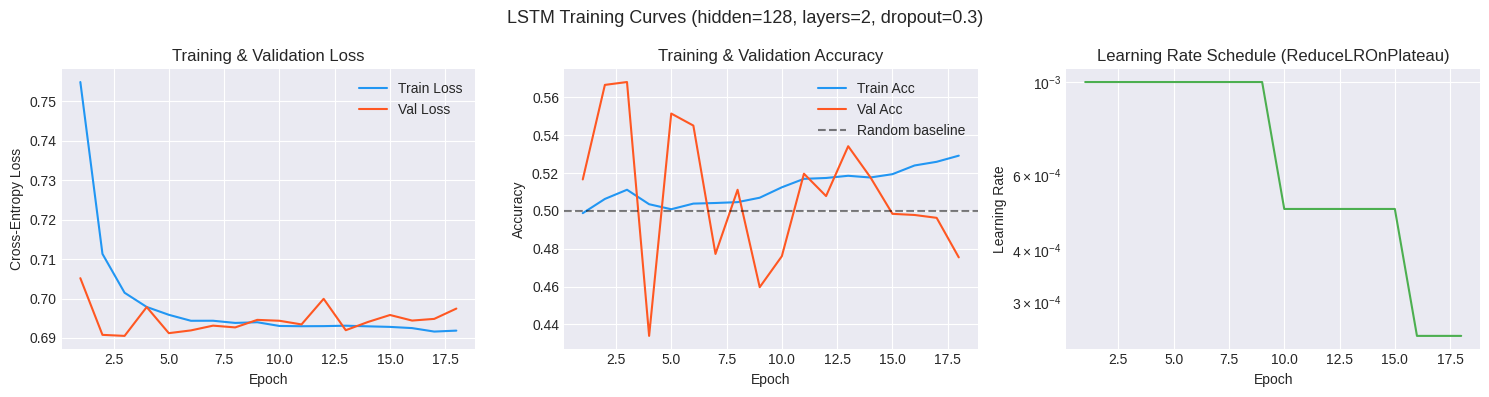

Best val_acc: 0.5682
Best val_loss: 0.6905


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='#FF5722')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='#2196F3')
axes[1].plot(epochs, history['val_acc'], label='Val Acc', color='#FF5722')
axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()

# Learning rate schedule
axes[2].plot(epochs, history['lr'], color='#4CAF50')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule (ReduceLROnPlateau)')
axes[2].set_yscale('log')

plt.suptitle('LSTM Training Curves (hidden=128, layers=2, dropout=0.3)', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val_acc: {max(history["val_acc"]):.4f}')
print(f'Best val_loss: {min(history["val_loss"]):.4f}')

## 5. Hyperparameter Search (Grid Search)

In [8]:
# Grid search over 6 configurations (requirement: >= 3)
search = HyperparameterSearch(
    input_size=X_train.shape[1],
    train_loader=train_loader,
    val_loader=val_loader,
    grid=SMALL_GRID,
    epochs_per_trial=30,
    patience=8,
    device=DEVICE,
    class_weights=class_weights,
)

best_config, all_results = search.run()
print('\n=== Hyperparameter Search Results ===')
print(search.summary_table())
print(f'\nBest configuration: {best_config}')


Early stopping at epoch 12 — best val_loss=0.6913  (25.9s total)

Early stopping at epoch 16 — best val_loss=0.6924  (34.3s total)

Early stopping at epoch 15 — best val_loss=0.6913  (32.1s total)

Early stopping at epoch 12 — best val_loss=0.6897  (25.6s total)

Early stopping at epoch 15 — best val_loss=0.6914  (41.9s total)

Early stopping at epoch 16 — best val_loss=0.6910  (44.8s total)

=== Hyperparameter Search Results ===
| hidden | layers | dropout | lr     | val_acc | val_loss | epochs |
|--------|--------|---------|--------|---------|----------|--------|
|    256 |      2 |     0.2 | 0.0010 |  0.5682 |   0.6914 |     15 |
|    128 |      2 |     0.3 | 0.0010 |  0.5673 |   0.6897 |     12 |
|    256 |      2 |     0.3 | 0.0010 |  0.5673 |   0.6910 |     16 |
|    128 |      2 |     0.2 | 0.0010 |  0.5664 |   0.6913 |     15 |
|     64 |      2 |     0.2 | 0.0010 |  0.5627 |   0.6913 |     12 |
|     64 |      2 |     0.3 | 0.0010 |  0.5312 |   0.6924 |     16 |

Best configu

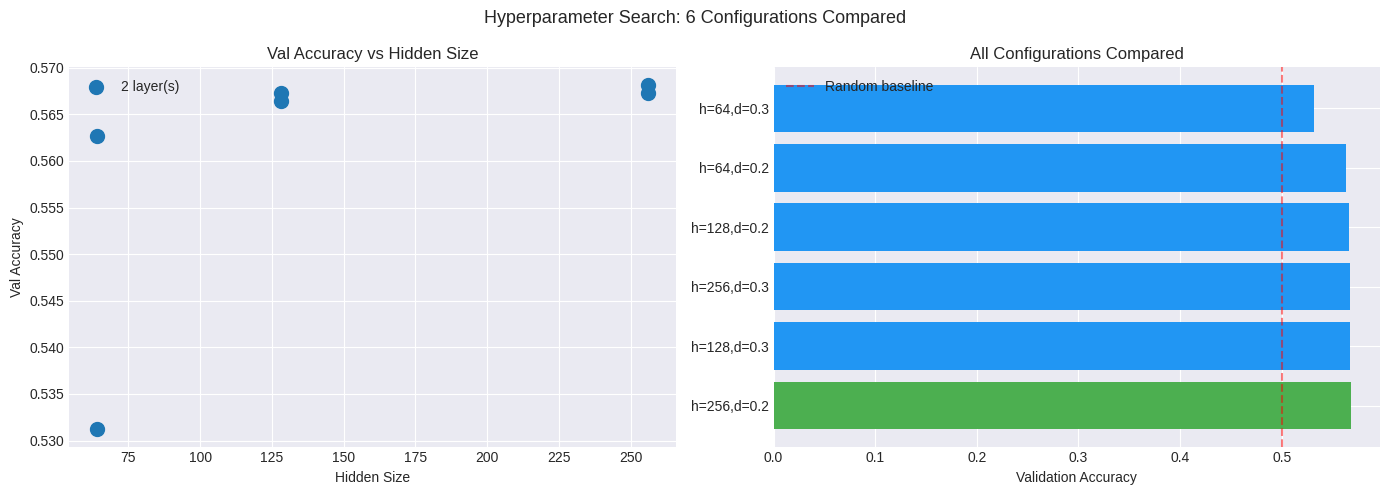

In [9]:
# Visualize hyperparameter search results
results_df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val accuracy by hidden size
for layers in results_df['num_layers'].unique():
    subset = results_df[results_df['num_layers'] == layers]
    axes[0].scatter(subset['hidden_size'], subset['val_acc'],
                   s=100, label=f'{layers} layer(s)')
axes[0].set_xlabel('Hidden Size')
axes[0].set_ylabel('Val Accuracy')
axes[0].set_title('Val Accuracy vs Hidden Size')
axes[0].legend()

# Summary bar chart
labels_hp = [f"h={r['hidden_size']},d={r['dropout']}" for r in all_results]
val_accs = [r['val_acc'] for r in all_results]
colors_hp = ['#4CAF50' if r == max(val_accs) else '#2196F3' for r in val_accs]
axes[1].barh(labels_hp, val_accs, color=colors_hp)
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Validation Accuracy')
axes[1].set_title('All Configurations Compared')
axes[1].legend()

plt.suptitle('Hyperparameter Search: 6 Configurations Compared', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tree Model Training

Tree train: 15,460  Val: 3,310  Test: 3,310
Tree model metrics:
  xgb_val_acc: 0.5030
  xgb_val_f1: 0.5502
  rf_val_acc: 0.4870
  rf_val_f1: 0.4762


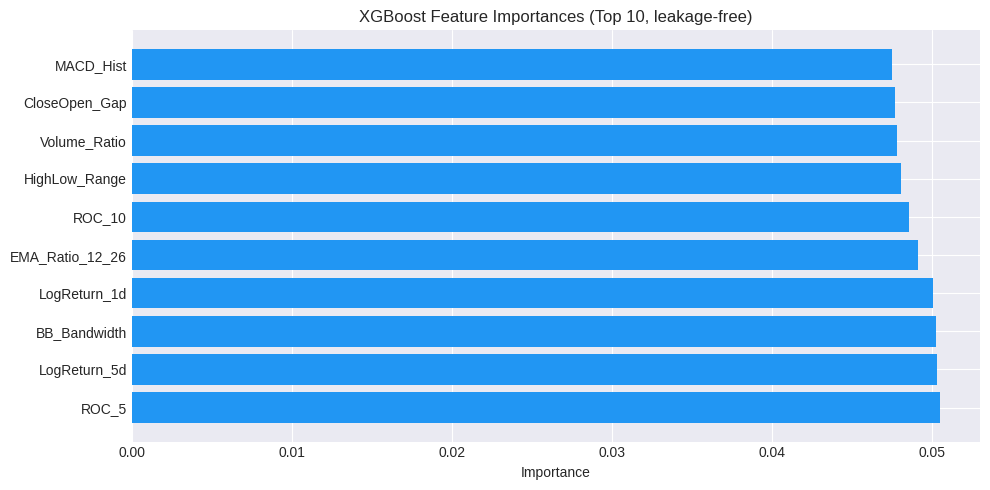

In [10]:
# For tree models we lag features by 1 day per ticker so we use
# yesterday's features to predict today's return — the same temporal
# alignment the LSTM uses (sequence ends at t-1, predicts t).
# Doing this per ticker before concatenating prevents AAPL's last day
# from bleeding into MSFT's first day.
tr_X_lag, tr_y_lag = [], []
va_X_lag, va_y_lag = [], []
te_X_lag, te_y_lag = [], []

for X_chunk, ret_chunk in zip(tr_X, tr_ret):
    tr_X_lag.append(X_chunk[:-1])
    tr_y_lag.append((ret_chunk[1:] > 0).astype(int))

for X_chunk, ret_chunk in zip(va_X, va_ret):
    va_X_lag.append(X_chunk[:-1])
    va_y_lag.append((ret_chunk[1:] > 0).astype(int))

for X_chunk, ret_chunk in zip(te_X, te_ret):
    te_X_lag.append(X_chunk[:-1])
    te_y_lag.append((ret_chunk[1:] > 0).astype(int))

X_tree_train = preprocessor.transform(np.concatenate(tr_X_lag))
X_tree_val   = preprocessor.transform(np.concatenate(va_X_lag))
X_tree_test  = preprocessor.transform(np.concatenate(te_X_lag))
y_tree_train = np.concatenate(tr_y_lag)
y_tree_val   = np.concatenate(va_y_lag)
y_tree_test  = np.concatenate(te_y_lag)

print(f'Tree train: {len(X_tree_train):,}  Val: {len(X_tree_val):,}  Test: {len(X_tree_test):,}')

tree_models = TreeEnsemble()
tree_metrics = tree_models.fit(X_tree_train, y_tree_train, X_tree_val, y_tree_val)
print('Tree model metrics:')
for k, v in tree_metrics.items():
    print(f'  {k}: {v:.4f}')

importance = tree_models.get_feature_importance(feature_cols)
top_10 = list(importance.items())[:10]

fig, ax = plt.subplots(figsize=(10, 5))
feat_names, importances = zip(*top_10)
ax.barh(list(feat_names), list(importances), color='#2196F3')
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importances (Top 10, leakage-free)')
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ensemble Training

Ensemble metrics: {'ensemble_val_acc': 0.566969696969697, 'ensemble_val_f1': 0.7236511313092245, 'meta_coefficients': [[-0.32560996378671253, 0.391811851617125, -0.2310277699452023, 0.29723018956726444, 0.017055862693055163, 0.049146523360826734]]}

Model Comparison on Validation Set:
  LSTM: 0.5582
  XGBoost: 0.5027
  Random Forest: 0.4870
  Ensemble: 0.5670


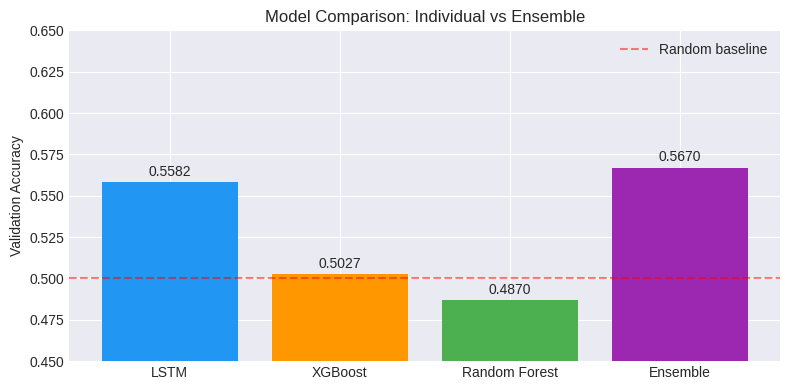

In [11]:
# Get validation predictions from all models
val_lstm_proba = trainer.predict_proba(val_loader)
n_align = len(val_lstm_proba)
val_xgb_proba, val_rf_proba = tree_models.predict_proba(X_tree_val[:n_align])
val_labels = y_tree_val[:n_align]

ensemble = EnsembleModel()
ensemble_metrics = ensemble.fit_meta_learner(
    val_lstm_proba, val_xgb_proba, val_rf_proba, val_labels
)
print('Ensemble metrics:', ensemble_metrics)

from sklearn.metrics import accuracy_score, f1_score

comparison = {
    'LSTM': accuracy_score(val_labels, val_lstm_proba.argmax(axis=1)),
    'XGBoost': accuracy_score(val_labels, val_xgb_proba.argmax(axis=1)),
    'Random Forest': accuracy_score(val_labels, val_rf_proba.argmax(axis=1)),
    'Ensemble': ensemble_metrics['ensemble_val_acc'],
}

print('\nModel Comparison on Validation Set:')
for m, acc in comparison.items():
    print(f'  {m}: {acc:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors_cmp = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = ax.bar(comparison.keys(), comparison.values(), color=colors_cmp)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Comparison: Individual vs Ensemble')
ax.legend()
ax.set_ylim(0.45, 0.65)
for bar, acc in zip(bars, comparison.values()):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../docs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Inference Timing

In [12]:
# Measure inference time for each model
import time

sample_X = torch.tensor(test_ds.X[:64], dtype=torch.float32).to(DEVICE)
model.eval()

# LSTM timing
times_lstm = []
for _ in range(20):
    with torch.no_grad():
        t0 = time.perf_counter()
        _ = model(sample_X)
        times_lstm.append(time.perf_counter() - t0)

lstm_timing = TradingMetrics.measure_inference_time(
    lambda x: model(torch.tensor(x, dtype=torch.float32).to(DEVICE)),
    test_ds.X[:64]
)

print('Inference Timing Results:')
print(f'  LSTM mean latency:  {np.mean(times_lstm)*1000:.3f} ms')
print(f'  LSTM throughput:    {64/np.mean(times_lstm):.1f} samples/sec')
print(f'  Full timing report: {lstm_timing}')

Inference Timing Results:
  LSTM mean latency:  0.547 ms
  LSTM throughput:    116939.8 samples/sec
  Full timing report: {'mean_latency_ms': 0.662, 'std_latency_ms': 0.013, 'throughput_samples_per_sec': 96605.7, 'n_trials': 20}
